In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path
base_path = Path('/content/drive/MyDrive/przetwarzanie_wizualizacja_danych')

In [ ]:
pip install optuna

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import optuna

In [ ]:
df = pd.read_csv(base_path / 'titanic.csv', index_col= 'PassengerId')

In [ ]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Przygotowanie danych

#####Takie same transformacje co w zadaniu 1, tylko osobno dla X_train i X_test (używając wyników X_train), aby zapobiec data leakage

## Zmiany na całym df

In [ ]:
mapping = {'male' : 1, 'female' : 0}
df['Is_Male'] = df['Sex'].map(mapping)

df['Deck'] = df['Cabin'].str[0]
df = df.drop(columns = ['Cabin'])

df['Family_size'] = df['SibSp'] + df['Parch'] + 1

In [ ]:
def get_cabins(df, ticket_duplicates):

  for t in ticket_duplicates:
    for k in df.Deck.dropna().unique():
      if ((df['Ticket'] == t) & (df['Deck'] == k)).any():
        df.loc[(df['Ticket'] == t) & (df['Deck'].isna()), 'Deck'] = k
  return df

In [ ]:
df['Ticket'] = df['Ticket'].str.strip()
ticket_duplicates = df.loc[df.Ticket.duplicated(), 'Ticket'].unique()
same_ticket = df[(df['Ticket'].isin(ticket_duplicates)) & ((df['Pclass'] == 1) | (df['Pclass'] == 2))]
same_tickets = get_cabins(same_ticket, ticket_duplicates)
df.loc[same_ticket.index, 'Deck'] = same_tickets['Deck']

In [ ]:
pclass_3_male_alone = df[(df['Pclass'] == 3) & (df['Parch'] == 0) & (df['Sex'] == 'male')]
pclass_3_other = df[(df['Pclass'] == 3) & ~(df.index.isin(pclass_3_male_alone.index))]
pclass_1 = df[(df['Pclass'] == 1)]

for i in df.index:
    if i in pclass_3_male_alone.index:
     df.loc[i, 'Section'] = 'bow'
    elif i in pclass_3_other.index:
     df.loc[i, 'Section'] = 'stern'
    elif i in pclass_1.index:
     df.loc[i, 'Section'] = 'midship'
    else:
     df.loc[i, 'Section'] = 'midship_aft'


## Zmiany osobno dla X_train, X_test

In [ ]:
X = df.drop(columns = ['Survived', 'Name'])
y = df['Survived']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = 0.8, shuffle = True, random_state = 0)

In [ ]:
fare_medians_by_class = X_train.groupby('Pclass')['Fare'].median().to_dict()
age_medians_by_class = X_train.groupby('Pclass')['Age'].median().to_dict()
embarked_mode = X_train['Embarked'].mode()[0]

deck_dist = X_train['Deck'].value_counts(normalize = True)
deck_values = deck_dist.index
deck_probs = deck_dist.values
deck_values.tolist()
deck_probs.tolist();

In [ ]:
def fill_missing_vals(X_train, X_test):

 X_train["Fare"] = X_train["Fare"].fillna(X_train["Pclass"].map(fare_medians_by_class))
 X_train["Age"] = X_train["Age"].fillna(X_train["Pclass"].map(age_medians_by_class))
 X_train["Embarked"] = X_train["Embarked"].fillna(embarked_mode)
 X_train.loc[X_train['Deck'].isna(), 'Deck'] = np.random.default_rng(seed=0).choice(deck_values, size = X_train['Deck'].isna().sum(), p = deck_probs)

 X_test["Fare"] = X_test["Fare"].fillna(X_test["Pclass"].map(fare_medians_by_class))
 X_test["Age"] = X_test["Age"].fillna(X_test["Pclass"].map(age_medians_by_class))
 X_test["Embarked"] = X_test["Embarked"].fillna(embarked_mode)
 X_test.loc[X_test['Deck'].isna(), 'Deck'] = np.random.default_rng(seed=1).choice(deck_values, size = X_test['Deck'].isna().sum(), p = deck_probs)

 return X_train, X_test


In [ ]:
X_train, X_test = fill_missing_vals(X_train, X_test)

print(X_train.isna().sum().sum())
print(X_test.isna().sum().sum())

0
0


In [ ]:
people_on_ticket = X_train[X_train['Ticket'].isin(ticket_duplicates)]['Ticket'].value_counts()

In [ ]:
def feature_engeeniring(X):

  X['People_On_Ticket'] = X['Ticket'].map(people_on_ticket).fillna(1).astype('int')
  X['Fare_per_person'] = X['Fare'] / X['People_On_Ticket']
  X = X.drop(columns = ['Fare', 'People_On_Ticket'])

  for i in X.index:
    if X.loc[i, 'Fare_per_person'] >= 200:
      X.loc[i, 'Wealth_level'] = 'elite'
    elif (X.loc[i, 'Fare_per_person'] >= 53.23) & (X.loc[i, 'Fare_per_person'] < 200):
      X.loc[i, 'Wealth_level'] = 'wealthy'
    elif (X.loc[i, 'Fare_per_person'] >= 30) & (X.loc[i, 'Fare_per_person'] < 53.23):
      X.loc[i, 'Wealth_level'] = 'upper_class'
    elif (X.loc[i, 'Fare_per_person'] >= 12) & (X.loc[i, 'Fare_per_person'] < 30):
      X.loc[i, 'Wealth_level'] = 'middle_class'
    else:
      X.loc[i, 'Wealth_level'] = 'lower_class'

  return X

In [ ]:
X_train = feature_engeeniring(X_train)
X_test = feature_engeeniring(X_test);

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
def logarytm(df, col):
  df[f'{col}_log'] = np.log1p(df[col])
  df = df.drop(columns = [col])
  return df

In [ ]:
def transform(X_train, X_test):

    encoder = OneHotEncoder(sparse_output=False)

    X_train_encoded = encoder.fit_transform(X_train[['Section', 'Embarked']])
    X_test_encoded = encoder.transform(X_test[['Section', 'Embarked']])

    encoded_cols = encoder.get_feature_names_out(['Section', 'Embarked'])

    X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoded_cols, index=X_train.index)
    X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoded_cols, index=X_test.index)

    X_train = pd.concat([X_train.drop(columns=['Section', 'Embarked']), X_train_encoded], axis=1)
    X_test = pd.concat([X_test.drop(columns=['Section', 'Embarked']), X_test_encoded], axis=1)

    mapping = {
    'elite': 1,
    'wealthy': 2,
    'upper_class': 3,
    'middle_class': 4,
    'lower_class': 5,
}

    X_train['Wealth_level'] = X_train['Wealth_level'].map(mapping)
    X_test['Wealth_level'] = X_test['Wealth_level'].map(mapping)

    labels_mapping = {
    k: i for i, k in enumerate(sorted(X_train['Deck'].unique()))
}

    X_train['Deck'] = X_train.Deck.map(labels_mapping)
    X_train.loc[X_train['Deck'] == 7, 'Deck'] = 0

    X_test['Deck'] = X_test.Deck.map(labels_mapping)
    X_test.loc[X_test['Deck'] == 7, 'Deck'] = 0

    X_train = logarytm(X_train, 'Fare_per_person')
    X_test = logarytm(X_test, 'Fare_per_person')

    age_min = X_train['Age'].min()
    age_max = X_train['Age'].max()

    X_train['Age_normalized'] = (X_train['Age'] - age_min) / (age_max - age_min)
    X_test['Age_normalized'] = (X_test['Age'] - age_min) / (age_max - age_min)

    return X_train, X_test

In [ ]:
X_train, X_test = transform(X_train, X_test)

In [ ]:
X_train = X_train.drop(columns = ['SibSp', 'Parch', 'Ticket', 'Age', 'Sex'])
X_test = X_test.drop(columns = ['SibSp', 'Parch', 'Ticket', 'Age', 'Sex']);

In [ ]:
X_train.head(5)

,Pclass,Is_Male,Deck,Family_size,Wealth_level,Section_bow,Section_midship,Section_midship_aft,Section_stern,Embarked_C,Embarked_Q,Embarked_S,Fare_per_person_log,Age_normalized
PassengerId,,,,,,,,,,,,,,
141,3,0,4,3,5,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2.154421,0.294088
440,2,1,2,1,5,0.0,0.0,1.0,0.0,0.0,0.0,1.0,2.442347,0.382327
818,2,1,2,3,4,0.0,0.0,1.0,0.0,1.0,0.0,0.0,2.970522,0.382327
379,3,1,2,1,5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.611935,0.243666
492,3,1,3,1,5,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.110213,0.256271


In [ ]:
X_test.head(5)

,Pclass,Is_Male,Deck,Family_size,Wealth_level,Section_bow,Section_midship,Section_midship_aft,Section_stern,Embarked_C,Embarked_Q,Embarked_S,Fare_per_person_log,Age_normalized
PassengerId,,,,,,,,,,,,,,
496,3,1,4,1,5,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.202765,0.294088
649,3,1,5,1,5,1.0,0.0,0.0,0.0,0.0,0.0,1.0,2.145931,0.294088
279,3,1,2,6,5,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2.113994,0.079793
32,1,0,1,2,2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,4.993969,0.457960
256,3,0,5,3,4,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2.787834,0.357116


# Modelowanie

# Baseline

Strategia 'uniform' oznacza przypisanie dokładnie takiego samego prawdopodobieństwa każdej unikalnej klasie.

W tym przypadku, 50/50 dla dwóch unikatowych klas 0 i 1.

In [ ]:
from sklearn.dummy import DummyClassifier

In [ ]:
dummy = DummyClassifier(strategy = 'uniform', random_state=0)
dummy.fit(X_train, y_train)
y_pred = dummy.predict(X_test)
baseline_accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline: {baseline_accuracy:.3f}")

Baseline: 0.542


# SVC

Model SVC szuka hiperpłaszczyzny, która dzieli klasy jak z największym marginesem. Ten model jest bardzo wrażliwy na skalowanie danych.

Hiperparametry:

*   C - kontroluje margines. Małe C oznacza większą tolerancję na błędy i szerszy margines,
*   kernel - rodzaj funkcji jądrowej, która pozwala na rzutowanie danych do większych wymiarów w celu znalezienia nieliniowych granic,
*   gamma - zasięg wpływu pojedynczego punktu treningowego. Duże gamma oznacza wąski zasięg i ryzyko overfittingu przez to że model dopasowuje się do każdego punktu.



In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [ ]:
def objective(trial):

    params = {
    'C' : trial.suggest_categorical("C", np.logspace(-1, 1, 3).tolist()),
    'gamma' : trial.suggest_categorical("gamma", ['scale'] + np.logspace(-1, 1, 3).tolist()),
    'kernel' : trial.suggest_categorical("kernel", ['rbf', 'linear'])
    }

    svc = SVC(**params, probability=True, random_state = 0)

    clf = make_pipeline(StandardScaler(), svc)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

    score = cross_val_score(clf, X_train, y_train, cv=cv, n_jobs=-1,  scoring="roc_auc").mean()

    return score


Standard Scaler transformuje dane osobno dla poszczególnych podzbiorów treningowych cross-validacji.

Dzięki StratifiedKFold dane zostały wymieszane przed cross-validacją.

Metryka Roc_auc sprawdza niezależnie od granicy odcięcia (domyślnie 50%) czy model ma zdolność do rozróżniania klas.

In [ ]:
study_svc = optuna.create_study(direction="maximize", sampler = optuna.samplers.TPESampler(seed=0))

[I 2026-08-16 19:49:13,921] A new study created in memory with name: no-name-436ea02c-d877-4f70-a8ff-6b80a7a48461


In [ ]:
study_svc.optimize(objective, n_trials=20)

[I 2026-08-16 19:49:18,734] Trial 0 finished with value: 0.8146240091616267 and parameters: {'C': 1.0, 'gamma': 1.0, 'kernel': 'linear'}. Best is trial 0 with value: 0.8146240091616267.
[I 2026-08-16 19:49:19,359] Trial 1 finished with value: 0.8146240091616267 and parameters: {'C': 1.0, 'gamma': 0.1, 'kernel': 'linear'}. Best is trial 0 with value: 0.8146240091616267.
[I 2026-08-16 19:49:20,008] Trial 2 finished with value: 0.832696901090318 and parameters: {'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}. Best is trial 2 with value: 0.832696901090318.
[I 2026-08-16 19:49:20,375] Trial 3 finished with value: 0.8244975882123218 and parameters: {'C': 0.1, 'gamma': 0.1, 'kernel': 'linear'}. Best is trial 2 with value: 0.832696901090318.
[I 2026-08-16 19:49:22,130] Trial 4 finished with value: 0.8168453606071161 and parameters: {'C': 10.0, 'gamma': 10.0, 'kernel': 'linear'}. Best is trial 2 with value: 0.832696901090318.
[I 2026-08-16 19:49:22,793] Trial 5 finished with value: 0.81743498200

In [ ]:
import optuna.visualization as vis

In [ ]:
vis.plot_optimization_history(study_svc)


Algorytm szybko się ustabilizował, co oznacza, że znalazł optymalne parametry

In [ ]:
print("Best hyperparameters:", study_svc.best_params)
print("Best roc_auc:", study_svc.best_value)

Best hyperparameters: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Best roc_auc: 0.848255068976072


Roc_auc = 0.836 oznacza wysoką zdolność modelu do rozróżniania klas.

In [ ]:
optuna.visualization.plot_param_importances(study_svc)

Największy wpływ na metrykę miał parametr gamma.

In [ ]:
optuna.visualization.plot_slice(study_svc)

Metryka Roc_auc nieznacznie się różni ze względu na parametr C.

Najlepszy parametr gamma = 'scale' oznacza automatyczne obliczanie gammy na podstawie zbioru danych.

Kernel 'rbf' jest bardziej optymalny niż 'linear'

Trening modelu z najlepszymi parametrami:

In [ ]:
best_svc_model = make_pipeline(StandardScaler(), SVC(**study_svc.best_params, probability=True, random_state=0))

In [ ]:
best_svc_model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(probability=True, random_state=0))])

In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
y_proba_train = best_svc_model.predict_proba(X_train)
roc_auc_train = roc_auc_score(y_train, y_proba_train[:,1])
print(f"SVC Train ROC AUC: {roc_auc_train:.3f}")
y_proba_test = best_svc_model.predict_proba(X_test)
roc_auc_test = roc_auc_score(y_test,  y_proba_test[:,1])
print(f"SVC Test ROC AUC:  {roc_auc_test:.3f}")

SVC Train ROC AUC: 0.886
SVC Test ROC AUC:  0.868


Model dobrze rozróżnia klasy również w danych testowych

In [ ]:
y_pred = best_svc_model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.94      0.87       110
           1       0.87      0.65      0.74        69

    accuracy                           0.83       179
   macro avg       0.84      0.79      0.81       179
weighted avg       0.83      0.83      0.82       179



In [ ]:
accuracy_svc = accuracy_score(y_test, y_pred)

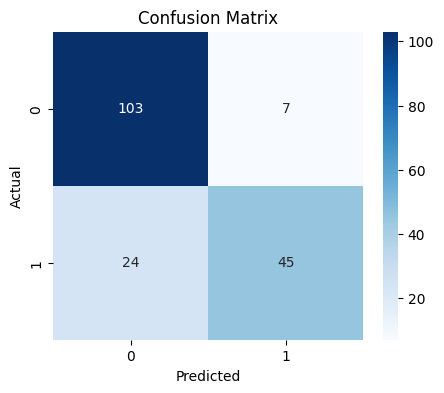

In [ ]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model ma wysoką dokładność 0.83, jednak ma problem z wysoką liczbą błędów False Negative, klasyfikując ocalałych jako zmarłych

# XGBoost

Model XGBoost łączy drzewa decyzyjne, gdzie każde drzewo uczy się na błędach poprzedniego. Ten model jest odporny na skalowanie danych i dobiera zmienne automatycznie.




Hiperparametry:

*   learning rate (od 0 do 1) - skalowanie wkładu każdego drzewa do predykcji,
*   max_depth - maksymalna głębokość drzewa,
*   n_estimators - ilość drzew,
*   subsample - ilość danych używanych przez pojedyncze drzewo,
*   colsample_bytree (od 0 do 1) - losowy wybór zmiennych,
*   min_child_weight - minimalna wartość sumy wag obserwacji wewnąrz liścia do podziału,
*   reg_alpha - regularyzacja L1 odcina korekty w liściach mniejsze niż alpha,
*   reg_lambda - regularyzacja L2 zmniejsza wartość korekt w liściach,
*   gamma - minimalna wartość Gain do podziału.



In [ ]:
from xgboost import XGBClassifier

In [ ]:
def objective(trial):

    params = {
    'learning_rate' : trial.suggest_float("learning_rate", 0.01, 0.1),
    'max_depth' : trial.suggest_int("max_depth", 2, 5),
    'n_estimators' : trial.suggest_int("n_estimators", 50, 200),
    'subsample' : trial.suggest_float("subsample", 0.6, 0.8, step = 0.1),
    'colsample_bytree' : trial.suggest_float("colsample_bytree", 0.4, 0.7, step=0.1),
    'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
    'reg_alpha' : trial.suggest_float("reg_alpha", 0.0, 1.0),
    'reg_lambda' : trial.suggest_float( "reg_lambda", 1.0, 10.0),
    'gamma' : trial.suggest_float("gamma", 0, 5)
    }

    clf = XGBClassifier(
        **params,
        objective='binary:logistic',
        eval_metric="auc",
        tree_method="hist",
        device="cuda",
        random_state = 0
    )

    score = cross_val_score(clf, X_train, y_train, cv=5, n_jobs=-1, scoring="roc_auc").mean()

    return score


tree_method="hist" (szybsza metoda budowania drzew) i device="cuda"(czyli użycie GPU) - przyspieszają trenowanie modelu

In [ ]:
study_xgb = optuna.create_study(direction="maximize", sampler = optuna.samplers.TPESampler(seed=0))

[I 2026-08-16 19:49:43,210] A new study created in memory with name: no-name-7ae0c414-ddac-4a31-acb1-c1ce8f21d2ba


In [ ]:
study_xgb.optimize(objective, n_trials=20)

[I 2026-08-16 19:49:44,710] Trial 0 finished with value: 0.8332614150913524 and parameters: {'learning_rate': 0.05939321535345923, 'max_depth': 4, 'n_estimators': 141, 'subsample': 0.7, 'colsample_bytree': 0.5, 'min_child_weight': 7, 'reg_alpha': 0.4375872112626925, 'reg_lambda': 9.025957007038718, 'gamma': 4.818313802505147}. Best is trial 0 with value: 0.8332614150913524.
[I 2026-08-16 19:49:45,557] Trial 1 finished with value: 0.8543227467992359 and parameters: {'learning_rate': 0.04450973669432, 'max_depth': 5, 'n_estimators': 129, 'subsample': 0.7, 'colsample_bytree': 0.7, 'min_child_weight': 1, 'reg_alpha': 0.08712929970154071, 'reg_lambda': 1.1819655769629316, 'gamma': 4.16309922773969}. Best is trial 1 with value: 0.8543227467992359.
[I 2026-08-16 19:49:46,550] Trial 2 finished with value: 0.8454119433625703 and parameters: {'learning_rate': 0.08003410758548654, 'max_depth': 5, 'n_estimators': 197, 'subsample': 0.8, 'colsample_bytree': 0.5, 'min_child_weight': 8, 'reg_alpha': 0

In [ ]:
vis.plot_optimization_history(study_xgb)

In [ ]:
print("Best hyperparameters:", study_xgb.best_params)
print("Best roc_auc:", study_xgb.best_value)

Best hyperparameters: {'learning_rate': 0.07569350817444621, 'max_depth': 3, 'n_estimators': 198, 'subsample': 0.8, 'colsample_bytree': 0.6000000000000001, 'min_child_weight': 2, 'reg_alpha': 0.9674418261157902, 'reg_lambda': 5.023825156840141, 'gamma': 0.25519037183026827}
Best roc_auc: 0.8597229346759127


In [ ]:
optuna.visualization.plot_param_importances(study_xgb)

Największy wpływ na metrykę miał parametr min_child_weight

In [ ]:
optuna.visualization.plot_slice(study_xgb)

Trening modelu z najlepszymi parametrami:

In [ ]:
best_xgb_model = XGBClassifier(**study_xgb.best_params, random_state=0)

In [ ]:
best_xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6000000000000001, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=0.25519037183026827, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.07569350817444621,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=2, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=198, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_proba_train = best_xgb_model.predict_proba(X_train)
roc_auc_train = roc_auc_score(y_train, y_proba_train[:,1])
print(f"XGBoost Train ROC AUC: {roc_auc_train:.3f}")
y_proba_test = best_xgb_model.predict_proba(X_test)
roc_auc_test = roc_auc_score(y_test,  y_proba_test[:,1])
print(f"XGBoost Test ROC AUC:  {roc_auc_test:.3f}")

XGBoost Train ROC AUC: 0.918
XGBoost Test ROC AUC:  0.904


Model dobrze rozróżnia klasy również w danych testowych

In [ ]:
y_pred = best_xgb_model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.94      0.88       110
           1       0.87      0.70      0.77        69

    accuracy                           0.84       179
   macro avg       0.85      0.82      0.83       179
weighted avg       0.85      0.84      0.84       179



In [ ]:
accuracy_xgb = accuracy_score(y_test, y_pred)

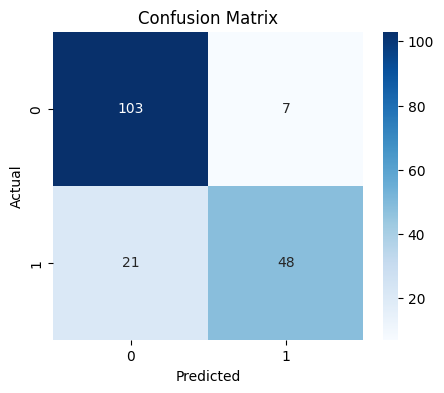

In [ ]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Model ma podobny problem do SVC - ma wysoką dokładność, ale też często klasyfikuje ocalałych jako zmarłych

In [ ]:
from xgboost import plot_importance

<Figure size 800x600 with 0 Axes>

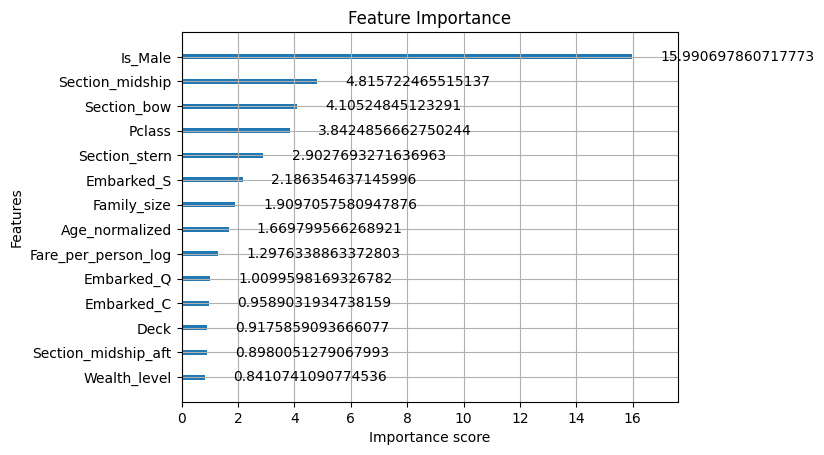

In [ ]:
plt.figure(figsize=(8,6))
plot_importance(best_xgb_model, importance_type="gain")
plt.title("Feature Importance")
plt.show()

Najbardziej wpływową cechą dla modelu okazała się płeć

# Porównanie modeli

In [ ]:
print(f"Accuracy baseline: {baseline_accuracy:.4f}")
print(f"Accuracy SVC: {accuracy_svc:.4f}")
print(f"Accuracy XGboost: {accuracy_xgb:.4f}")



Accuracy baseline: 0.5419
Accuracy SVC: 0.8268
Accuracy XGboost: 0.8436
